# Temporal Capability Tracking (2023-2026)

This notebook tracks intelligence progression and price compression across model generations using `release_year`.

Approach:
- Use both **median** and **mean** yearly statistics
- Treat **median** as primary (robust to outliers)
- Use **mean** as secondary context (tail effects)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

csv_path = "/content/drive/MyDrive/llm_price_performance_tracker_2026-03-31.csv"
df = pd.read_csv(csv_path)

# Standardize column names for consistent access
rename_map = {
    c: c.strip().lower().replace("\n", "_").replace(" ", "_").replace("-", "_")
    for c in df.columns
}
df = df.rename(columns=rename_map)

for col in ["release_year", "aa_intelligence_index", "blended_cost_usd_per_1m"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df.head(3)

,model_name,model_slug,provider,provider_slug,aa_id,aa_intelligence_index,aa_coding_index,aa_math_index,composite_benchmark,mmlu_pro,gpqa_diamond,humanitys_last_exam,livecodebench,scicode,math_500,aime_2025,input_cost_usd_per_1m,output_cost_usd_per_1m,blended_cost_usd_per_1m,pricing_tier,output_tokens_per_second,time_to_first_token_s,time_to_first_answer_s,chatbot_arena_elo,arena_elo_ci95,arena_votes,parameter_count,release_year,is_open_source,intelligence_per_dollar,price_performance_ratio,elo_benchmark_blend,speed_per_dollar,scrape_date
0,GPT-5.4 (xhigh),gpt-5-4,OpenAI,openai,a89c4b28-2d8c-456e-88ea-255fb51fd2b6,57.2,57.3,NaN,63.40,NaN,0.920,0.416,NaN,0.566,NaN,NaN,2.50,15.0,5.625,Premium,89.67,159.489,159.489,1466.0,8.0,5618.0,500.0,2026.0,False,10.17,33.53,80.68,15.94,2026-03-31
1,Gemini 3.1 Pro Preview,gemini-3-1-pro-preview,Google,google,bbd93ebe-80da-4594-bb19-61e69d0331df,57.2,55.5,NaN,65.90,NaN,0.941,0.447,NaN,0.589,NaN,NaN,2.00,12.0,4.500,Mid,120.21,36.314,36.314,1493.0,6.0,15809.0,NaN,2026.0,False,12.71,38.66,96.02,26.71,2026-03-31
2,GPT-5.3 Codex (xhigh),gpt-5-3-codex,OpenAI,openai,59b5b14b-5365-4ee7-824a-18a8e6309644,54.0,53.1,NaN,61.53,NaN,0.915,0.399,NaN,0.532,NaN,NaN,1.75,14.0,4.813,Mid,91.49,75.312,75.312,NaN,NaN,NaN,500.0,2026.0,False,11.22,34.96,NaN,19.01,2026-03-31


## Step 1: Build temporal analysis subset
Filter to years 2023-2026 and keep rows needed for intelligence/cost trend analysis.

In [4]:
years = [2023, 2024, 2025, 2026]

temporal_df = df[
    (df["release_year"].isin(years))
    & (df["aa_intelligence_index"].notna())
    & (df["blended_cost_usd_per_1m"].notna())
].copy()

temporal_df["release_year"] = temporal_df["release_year"].astype(int)

print(f"Rows in temporal subset: {len(temporal_df)}")
print("\nRows by year:")
display(temporal_df["release_year"].value_counts().sort_index())

Rows in temporal subset: 223

Rows by year:


,count
release_year,
2023,1
2024,43
2025,49
2026,130


## Step 2: Intelligence progression by year (median + mean)
Median is the primary trend; mean is included as secondary context.

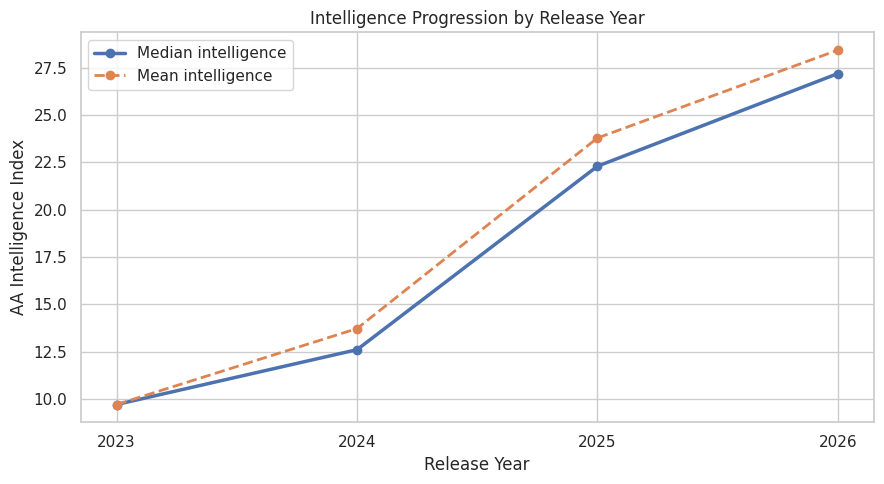

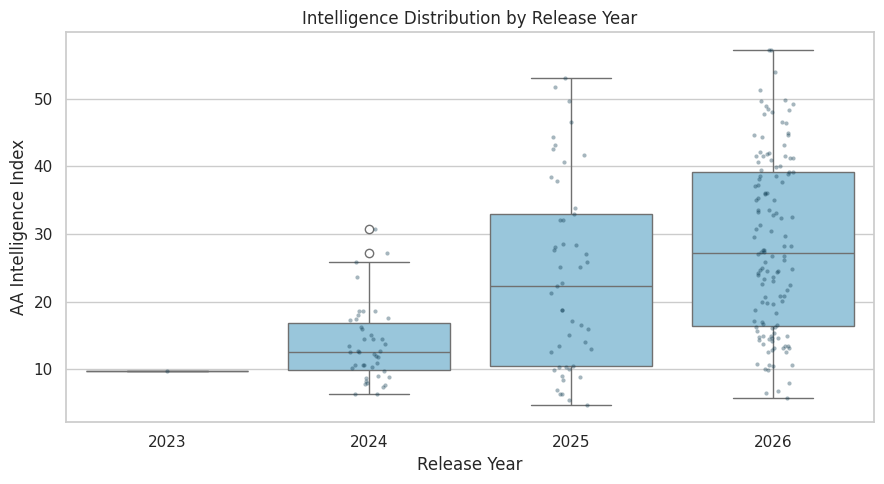

,release_year,median_intelligence,mean_intelligence,model_count
0,2023,9.7,9.700000,1
1,2024,12.6,13.716279,43
2,2025,22.3,23.793878,49
3,2026,27.2,28.440769,130


In [5]:
yearly_intel = (
    temporal_df.groupby("release_year")["aa_intelligence_index"]
    .agg(median_intelligence="median", mean_intelligence="mean", model_count="count")
    .reset_index()
)

plt.figure(figsize=(9, 5))
plt.plot(
    yearly_intel["release_year"],
    yearly_intel["median_intelligence"],
    marker="o",
    linewidth=2.5,
    label="Median intelligence",
)
plt.plot(
    yearly_intel["release_year"],
    yearly_intel["mean_intelligence"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Mean intelligence",
)
plt.title("Intelligence Progression by Release Year")
plt.xlabel("Release Year")
plt.ylabel("AA Intelligence Index")
plt.xticks(years)
plt.legend()
plt.tight_layout()
plt.show()

# Distribution view by year
plt.figure(figsize=(9, 5))
sns.boxplot(data=temporal_df, x="release_year", y="aa_intelligence_index", color="#8ecae6")
sns.stripplot(data=temporal_df, x="release_year", y="aa_intelligence_index", color="#023047", alpha=0.35, size=3)
plt.title("Intelligence Distribution by Release Year")
plt.xlabel("Release Year")
plt.ylabel("AA Intelligence Index")
plt.tight_layout()
plt.show()

yearly_intel

## Step 3: Price compression by year (median + mean)
Costs are plotted on a log scale because pricing is long-tailed.

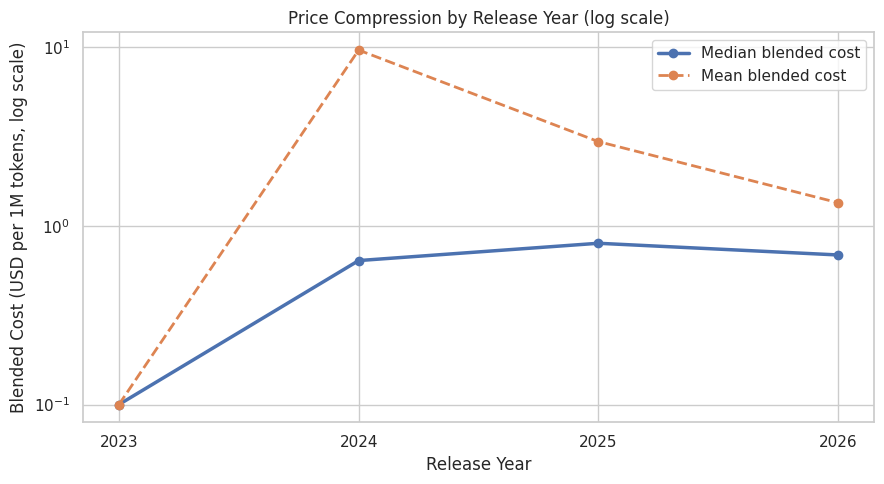

,release_year,median_cost,mean_cost,model_count,yoy_median_cost_pct
0,2023,0.100,0.100000,1,NaN
1,2024,0.640,9.662721,43,540.0
2,2025,0.800,2.968408,49,25.0
3,2026,0.688,1.349615,130,-14.0


In [6]:
yearly_cost = (
    temporal_df.groupby("release_year")["blended_cost_usd_per_1m"]
    .agg(median_cost="median", mean_cost="mean", model_count="count")
    .reset_index()
)

yearly_cost["yoy_median_cost_pct"] = yearly_cost["median_cost"].pct_change() * 100

plt.figure(figsize=(9, 5))
plt.plot(
    yearly_cost["release_year"],
    yearly_cost["median_cost"],
    marker="o",
    linewidth=2.5,
    label="Median blended cost",
)
plt.plot(
    yearly_cost["release_year"],
    yearly_cost["mean_cost"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Mean blended cost",
)
plt.yscale("log")
plt.title("Price Compression by Release Year (log scale)")
plt.xlabel("Release Year")
plt.ylabel("Blended Cost (USD per 1M tokens, log scale)")
plt.xticks(years)
plt.legend()
plt.tight_layout()
plt.show()

yearly_cost

## Step 4: Capability-price frontier over time
Scatter plot of cost vs intelligence colored by year to visualize movement toward better quality at lower cost.

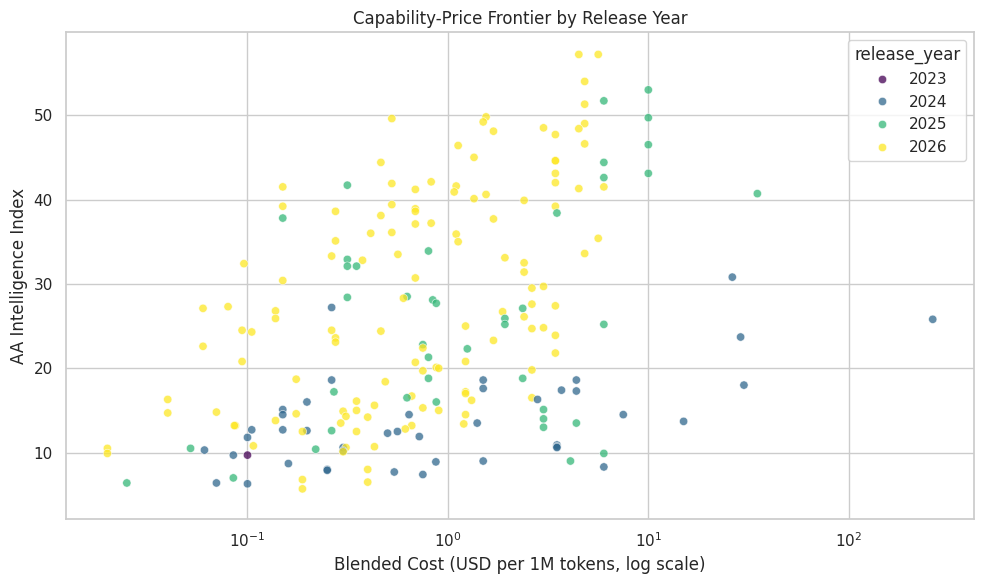

In [7]:
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=temporal_df,
    x="blended_cost_usd_per_1m",
    y="aa_intelligence_index",
    hue="release_year",
    palette="viridis",
    alpha=0.75,
)
ax.set_xscale("log")
ax.set_title("Capability-Price Frontier by Release Year")
ax.set_xlabel("Blended Cost (USD per 1M tokens, log scale)")
ax.set_ylabel("AA Intelligence Index")
plt.tight_layout()
plt.show()

## Step 5: Yearly summary and interpretation
A compact summary table and short narrative points.

In [8]:
summary = (
    temporal_df.groupby("release_year")
    .agg(
        models=("model_name", "count"),
        median_intelligence=("aa_intelligence_index", "median"),
        mean_intelligence=("aa_intelligence_index", "mean"),
        median_cost=("blended_cost_usd_per_1m", "median"),
        mean_cost=("blended_cost_usd_per_1m", "mean"),
    )
    .reset_index()
)

summary["yoy_median_intelligence"] = summary["median_intelligence"].diff()
summary["yoy_median_cost_pct"] = summary["median_cost"].pct_change() * 100

display(summary.round(3))

print("Interpretation guide:")
print("- Median lines reflect the typical model each year.")
print("- Mean lines reveal tail effects from very expensive or very capable outliers.")
print("- Negative YoY median cost % indicates price compression.")
print("- Positive YoY median intelligence indicates capability progression.")

,release_year,models,median_intelligence,mean_intelligence,median_cost,mean_cost,yoy_median_intelligence,yoy_median_cost_pct
0,2023,1,9.7,9.700,0.100,0.100,NaN,NaN
1,2024,43,12.6,13.716,0.640,9.663,2.9,540.0
2,2025,49,22.3,23.794,0.800,2.968,9.7,25.0
3,2026,130,27.2,28.441,0.688,1.350,4.9,-14.0


Interpretation guide:
- Median lines reflect the typical model each year.
- Mean lines reveal tail effects from very expensive or very capable outliers.
- Negative YoY median cost % indicates price compression.
- Positive YoY median intelligence indicates capability progression.
